# Random vs UCB Stochastic Approximation

Compare `StochasticApproximation` (pure random search) against `StochasticApproximationUCBDynamic` (UCB over an adaptive binary partition) on a list of trained `ReLUNet`s.

Pipeline per architecture:
1. Train the network on a synthetic regression target.
2. Choose UCB's `partition_step` from `PARTITION_GRID` by the mean final value over `TUNE_SEEDS` (UCB only; these seeds are not used afterwards).
3. Run both methods across `N_SEEDS` repeats with the full `COMPARE_ITERS` budget. UCB seeds are shifted by 1000, so the two methods draw independent random streams.
4. Plot mean ± std convergence bands vs iterations and vs wall-clock time.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import torch
import matplotlib.pyplot as plt

from relu_nets import ReLUNet
from hyperbox import Hyperbox
from experiments import runners

## Config — edit this cell

In [2]:
ARCHITECTURES = [
    [2, 32, 32, 1],
    [3, 32, 32, 32, 1],
    [4, 32, 32, 32, 1],
    [4, 64, 64, 64, 64, 1],
    [8, 32, 32, 32, 1],
    [8, 64, 64, 64, 64, 1],
]

DOMAIN_RADIUS = 1.0
PRIMAL_NORM   = 'linf'

TRAIN_SAMPLES = 4096
TRAIN_EPOCHS  = 1500
TRAIN_LR      = 1e-3
TRAIN_SEED    = 0

COMPARE_ITERS = 500_000
N_SEEDS       = 5
SEEDS         = list(range(N_SEEDS))
TUNE_SEEDS    = list(range(100, 100 + N_SEEDS))

UCB_C          = 15
PARTITION_GRID = [2, 1.5]

## Helpers

Both methods run through `experiments.runners.run_method`, i.e. the solvers of `other_methods` unchanged. Best-so-far curves are rebuilt from the improvement history each solver records (`[iteration, seconds, value]` at every new maximum).

In [3]:
def train_network(arch, n_samples, epochs, lr, domain_radius, seed=0):
    torch.manual_seed(seed); np.random.seed(seed)
    net = ReLUNet(arch)
    d = arch[0]
    X = (torch.rand(n_samples, d) * 2 - 1) * domain_radius
    y = torch.sin(X.norm(dim=1, keepdim=True)) + 0.1 * X[:, :1]
    opt  = torch.optim.Adam(net.parameters(), lr=lr)
    loss = torch.nn.MSELoss()
    for _ in range(epochs):
        opt.zero_grad()
        loss(net(X), y).backward()
        opt.step()
    return net


def best_so_far(history, column, points):
    """Running maximum at each of `points`, from an improvement history
    [[iteration, seconds, value], ...]; column 0 reads `points` as iterations, 1 as seconds."""
    if not history:
        return np.zeros(len(points))
    h = np.asarray(history, dtype=float)
    idx = np.searchsorted(h[:, column], points, side='right') - 1
    return np.where(idx >= 0, h[np.maximum(idx, 0), 2], 0.0)


def band(records, column, points):
    v = np.stack([best_so_far(r['history'], column, points) for r in records])
    return v.mean(axis=0), v.std(axis=0)

## Run the experiment

In [4]:
results, partition = {}, {}
for arch in ARCHITECTURES:
    print(f'=== {arch} ===')
    net = train_network(arch, TRAIN_SAMPLES, TRAIN_EPOCHS, TRAIN_LR, DOMAIN_RADIUS, seed=TRAIN_SEED)
    domain   = Hyperbox.build_custom_hypercube(arch[0], 0, DOMAIN_RADIUS)
    c_vector = torch.ones(arch[-1])

    tune = {tm: np.mean([runners.run_method('ucb', net, c_vector, domain, COMPARE_ITERS, s,
                                            primal_norm=PRIMAL_NORM, c=UCB_C, partition_step=tm)['value']
                         for s in TUNE_SEEDS])
            for tm in PARTITION_GRID}
    tm = partition[tuple(arch)] = max(tune, key=tune.get)
    print('  tuning: ' + ', '.join(f'partition_step {k}: {v:.4f}' for k, v in tune.items())
          + f'  ->  {tm}')

    runs = {'rand': [], 'ucb': []}
    for seed in SEEDS:
        rand = runners.run_method('uniform', net, c_vector, domain, COMPARE_ITERS, seed,
                                  primal_norm=PRIMAL_NORM)
        ucb = runners.run_method('ucb', net, c_vector, domain, COMPARE_ITERS, seed + 1000,
                                 primal_norm=PRIMAL_NORM, c=UCB_C, partition_step=tm)
        runs['rand'].append(rand)
        runs['ucb'].append(ucb)
        print(f"  seed {seed}: rand={rand['value']:.4f} ({rand['compute_time']:.2f}s)  "
              f"ucb={ucb['value']:.4f} ({ucb['compute_time']:.2f}s)")
    results[tuple(arch)] = runs

=== [2, 32, 32, 1] ===
  tuning: partition_step 2: 1.4315, partition_step 1.5: 1.4315  ->  2
  seed 0: rand=1.4315 (31.03s)  ucb=1.4315 (49.93s)
  seed 1: rand=1.4315 (31.09s)  ucb=1.4315 (49.68s)
  seed 2: rand=1.4315 (31.33s)  ucb=1.4315 (50.05s)
  seed 3: rand=1.4315 (31.03s)  ucb=1.4315 (51.61s)
  seed 4: rand=1.4315 (31.24s)  ucb=1.4315 (49.31s)
=== [3, 32, 32, 32, 1] ===
  tuning: partition_step 2: 1.9370, partition_step 1.5: 1.9370  ->  2
  seed 0: rand=1.9336 (36.78s)  ucb=1.9370 (55.44s)
  seed 1: rand=1.9336 (36.99s)  ucb=1.9370 (57.30s)
  seed 2: rand=1.9370 (36.67s)  ucb=1.9370 (58.34s)
  seed 3: rand=1.9336 (36.61s)  ucb=1.9370 (56.47s)
  seed 4: rand=1.9336 (36.65s)  ucb=1.9370 (55.99s)
=== [4, 32, 32, 32, 1] ===
  tuning: partition_step 2: 2.1820, partition_step 1.5: 2.1786  ->  2
  seed 0: rand=2.1582 (36.72s)  ucb=2.1879 (55.03s)
  seed 1: rand=2.1317 (36.48s)  ucb=2.1879 (53.89s)
  seed 2: rand=2.1582 (36.71s)  ucb=2.1879 (55.37s)
  seed 3: rand=2.1414 (36.52s)  ucb=2

## Convergence — mean ± std vs iterations and vs time

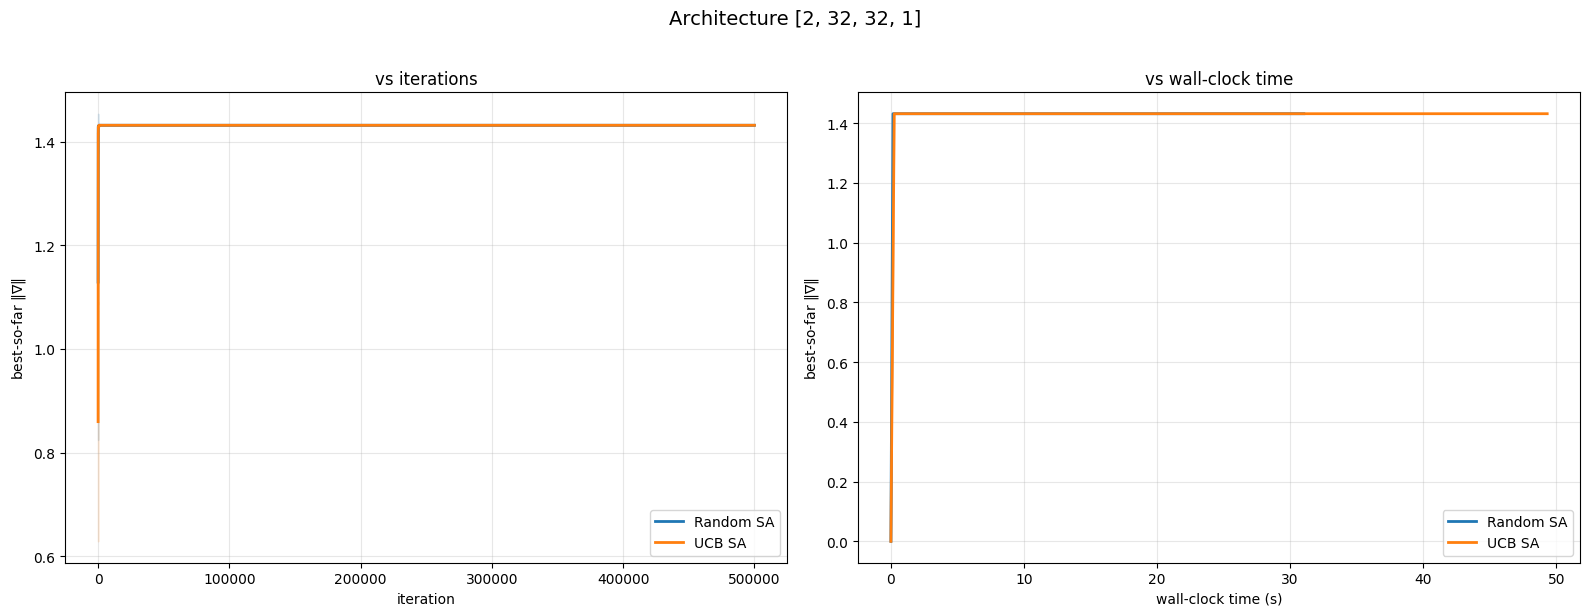

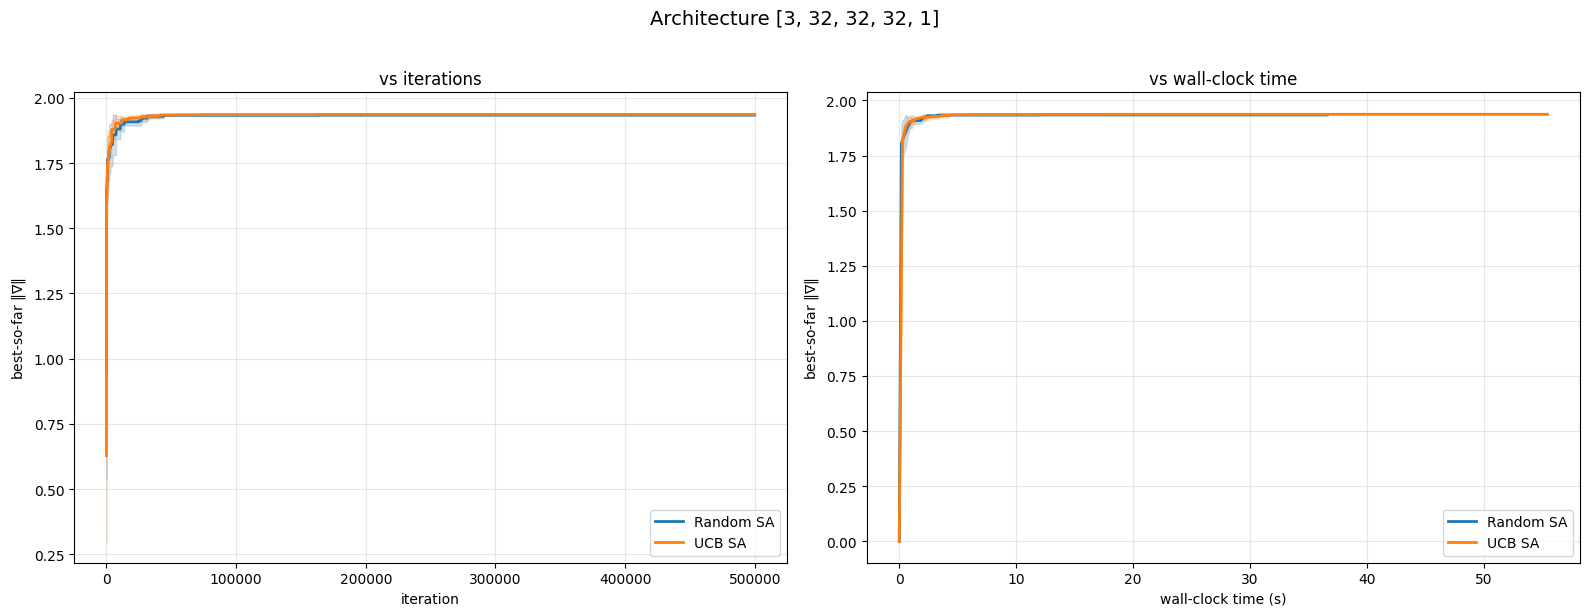

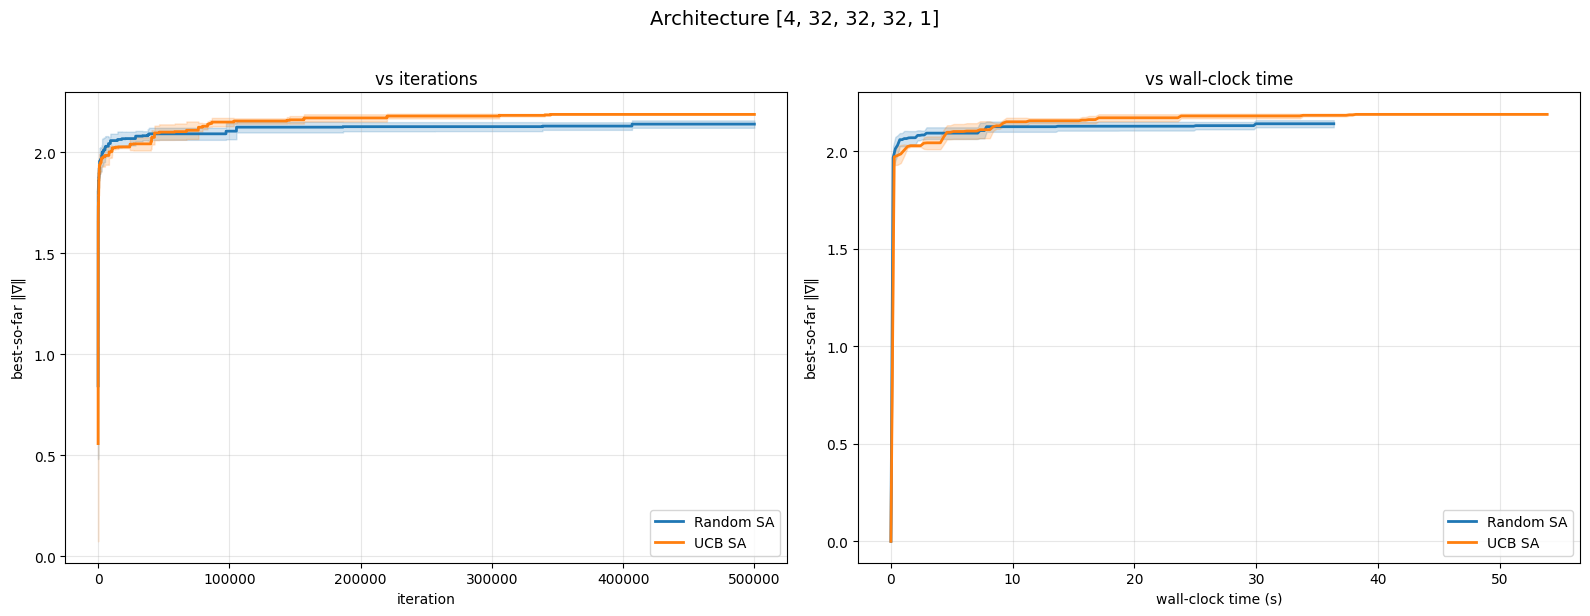

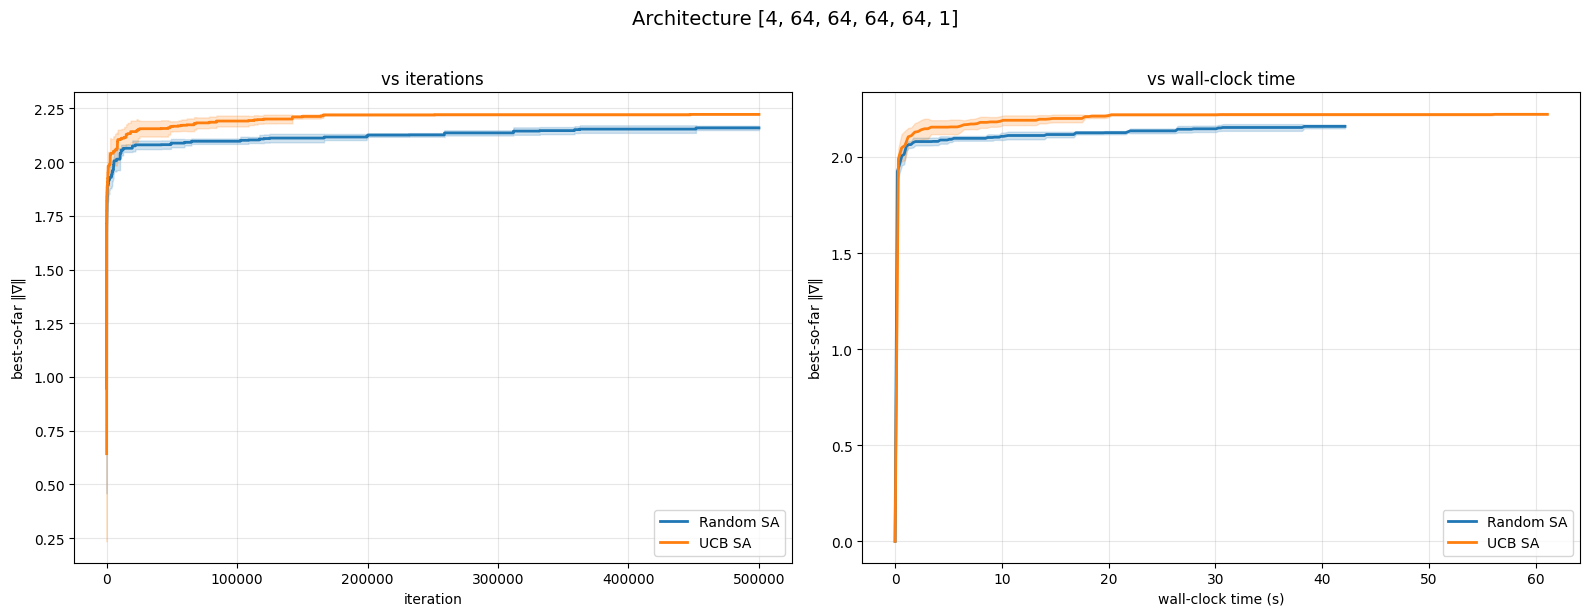

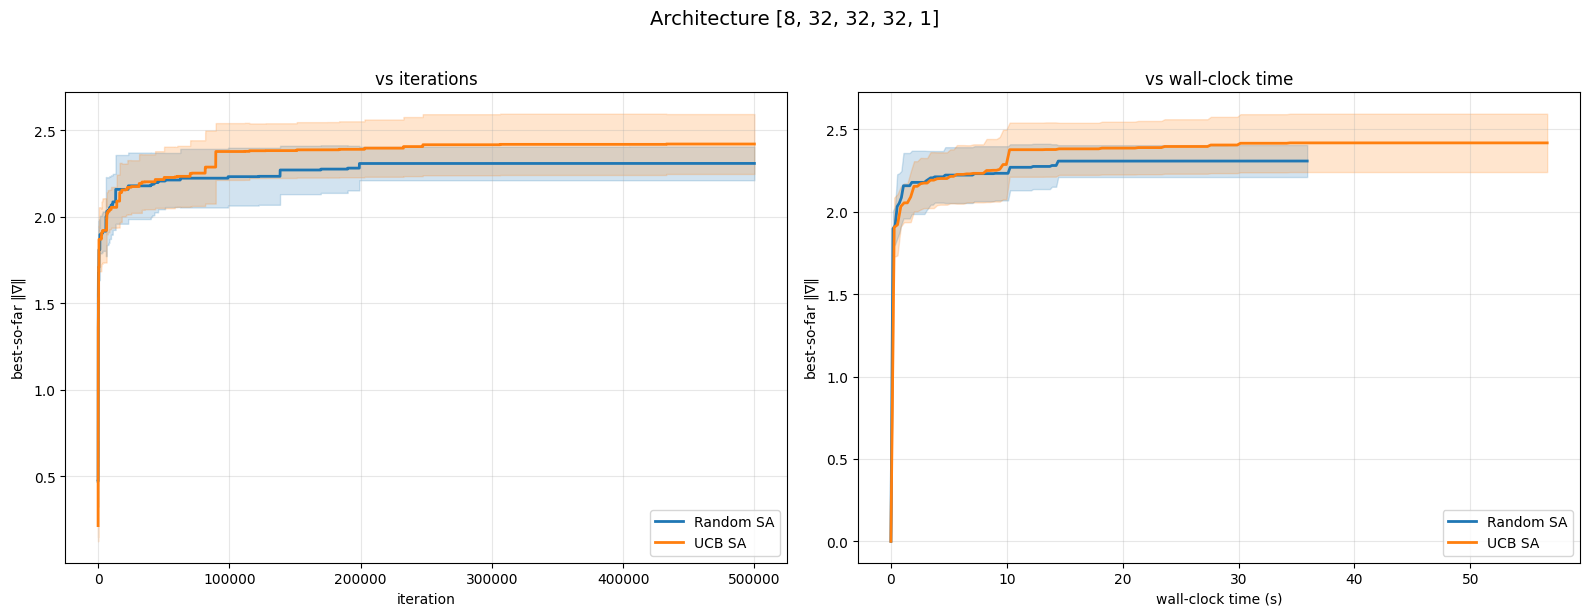

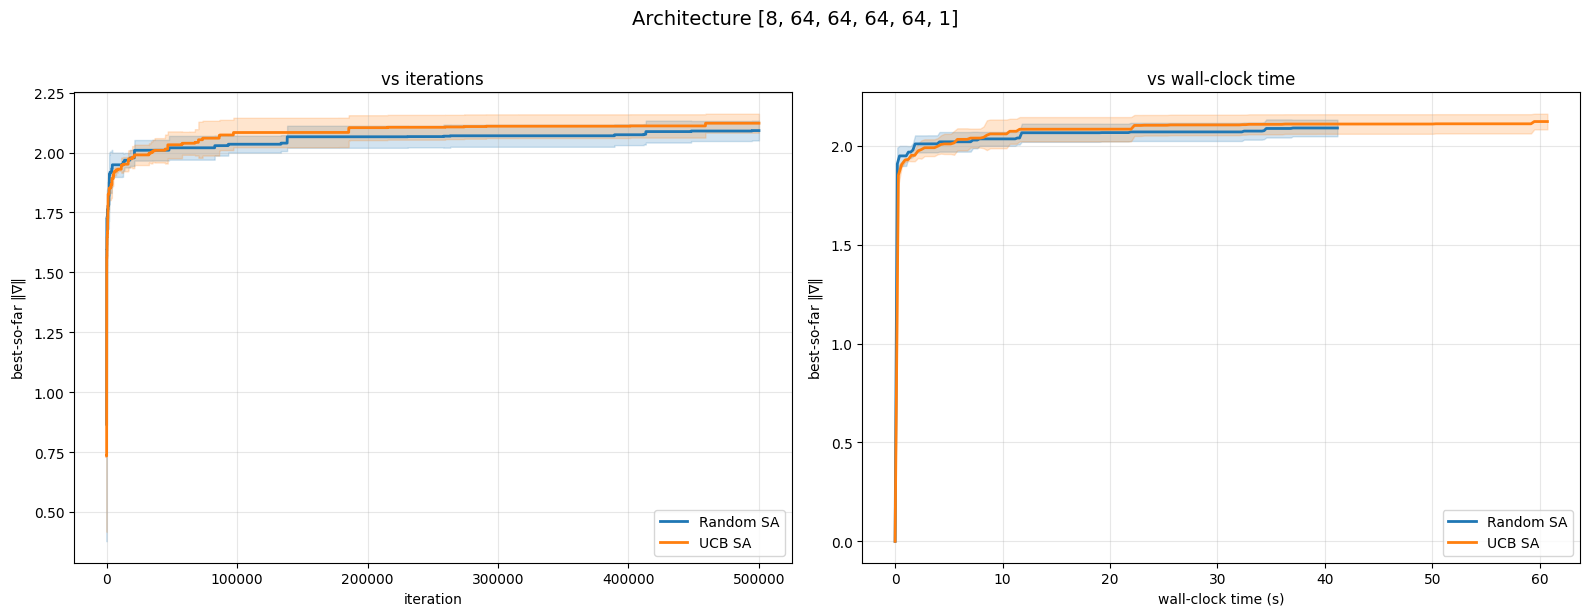

In [5]:
iters = np.arange(1, COMPARE_ITERS + 1)

for arch in ARCHITECTURES:
    runs = results[tuple(arch)]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'Architecture {arch}', fontsize=14, y=1.02)

    for label, key, color in [('Random SA', 'rand', 'tab:blue'), ('UCB SA', 'ucb', 'tab:orange')]:
        grid = np.linspace(0.0, min(r['compute_time'] for r in runs[key]), 200)
        for ax, column, points in [(axes[0], 0, iters), (axes[1], 1, grid)]:
            m, s = band(runs[key], column, points)
            ax.plot(points, m, label=label, color=color, linewidth=2)
            ax.fill_between(points, m - s, m + s, color=color, alpha=0.2)

    for ax, xlabel, title in [(axes[0], 'iteration', 'vs iterations'),
                              (axes[1], 'wall-clock time (s)', 'vs wall-clock time')]:
        ax.set_xlabel(xlabel)
        ax.set_ylabel(r'best-so-far $\|\nabla\|$')
        ax.set_title(title)
        ax.legend(loc='lower right')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Summary table

In [6]:
def fmt_meanstd(arr, unit='', precision=4):
    return f"{arr.mean():.{precision}f} ± {arr.std():.{precision}f}{unit}"


header = (f"{'arch':<22} {'method':>14} "
          f"{'final value':>22} {'total time':>20}")
print(header); print('-' * len(header))

for arch in ARCHITECTURES:
    runs = results[tuple(arch)]
    for method in ['rand', 'ucb']:
        finals = np.array([r['value'] for r in runs[method]])
        times  = np.array([r['compute_time'] for r in runs[method]])
        label = 'random' if method == 'rand' else f'ucb (t_m={partition[tuple(arch)]})'
        prefix_arch = str(arch) if method == 'rand' else ''
        print(f"{prefix_arch:<22} {label:>14} "
              f"{fmt_meanstd(finals, '', 4):>22} "
              f"{fmt_meanstd(times, ' s', 2):>20}")

arch                           method            final value           total time
---------------------------------------------------------------------------------
[2, 32, 32, 1]                 random        1.4315 ± 0.0000       31.15 ± 0.12 s
                          ucb (t_m=2)        1.4315 ± 0.0000       50.12 ± 0.79 s
[3, 32, 32, 32, 1]             random        1.9343 ± 0.0014       36.74 ± 0.14 s
                          ucb (t_m=2)        1.9370 ± 0.0000       56.71 ± 1.02 s
[4, 32, 32, 32, 1]             random        2.1398 ± 0.0182       36.56 ± 0.14 s
                          ucb (t_m=2)        2.1879 ± 0.0000       55.18 ± 0.73 s
[4, 64, 64, 64, 64, 1]         random        2.1590 ± 0.0099       42.20 ± 0.05 s
                          ucb (t_m=2)        2.2219 ± 0.0019       62.59 ± 0.95 s
[8, 32, 32, 32, 1]             random        2.3082 ± 0.0972       36.65 ± 1.01 s
                          ucb (t_m=2)        2.4202 ± 0.1732       60.73 ± 3.44 s
[8, 64, 64, 64, 